# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/124pritivarma6001-commits/flyrank_internship_ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [15]:
%pip -q install duckdb huggingface_hub

In [16]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [17]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [18]:
# Section 1: Ranked actions + reason codes

# ---------------------------------------------------------
# 1. Rebuild the validated content-level dataset
# ---------------------------------------------------------

model_data = con.sql(f"""
WITH daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(
            CASE
                WHEN gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        ) / NULLIF(SUM(gsc_impressions), 0) AS avg_position
    FROM read_parquet(
        '{REL}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE gsc_impressions IS NOT NULL
      AND gsc_clicks IS NOT NULL
      AND gsc_avg_position IS NOT NULL
    GROUP BY client_hash_id, content_hash_id
),
base AS (
    SELECT
        *,
        CAST(clicks AS DOUBLE) / NULLIF(impressions, 0) AS ctr
    FROM daily
    WHERE impressions > 0
)
SELECT
    client_hash_id,
    content_hash_id,
    impressions,
    clicks,
    ctr,
    avg_position,
    CASE
        WHEN impressions >= 237
         AND ctr < 0.003026
         AND avg_position <= 20
        THEN 1
        ELSE 0
    END AS opportunity
FROM base
WHERE ctr IS NOT NULL
  AND avg_position IS NOT NULL
""").df()

# ---------------------------------------------------------
# 2. Create the validated rule signals
# ---------------------------------------------------------

model_data["high_impressions"] = (
    model_data["impressions"] >= 237
)

model_data["low_ctr"] = (
    model_data["ctr"] < 0.003026
)

model_data["position_opportunity"] = (
    model_data["avg_position"] <= 20
)

# ---------------------------------------------------------
# 3. Create interpretable reason codes
# ---------------------------------------------------------

def make_reason_code(row):

    if row["opportunity"] != 1:
        return "NO_OPPORTUNITY"

    if (
        row["high_impressions"]
        and row["low_ctr"]
        and row["position_opportunity"]
    ):
        return "HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION"

    if row["high_impressions"] and row["low_ctr"]:
        return "HIGH_IMPRESSIONS_LOW_CTR"

    if row["low_ctr"] and row["position_opportunity"]:
        return "LOW_CTR_GOOD_POSITION"

    if row["high_impressions"]:
        return "HIGH_IMPRESSIONS"

    if row["position_opportunity"]:
        return "GOOD_POSITION"

    return "OPPORTUNITY_RULE_MATCH"


model_data["reason_code"] = model_data.apply(
    make_reason_code,
    axis=1
)

# ---------------------------------------------------------
# 4. Assign action
# ---------------------------------------------------------

model_data["recommended_action"] = np.where(
    model_data["opportunity"] == 1,
    "REVIEW_FOR_REFRESH",
    "NO_ACTION"
)

# ---------------------------------------------------------
# 5. Rank opportunities
#
# Priority:
#   1. Opportunity rows first
#   2. Higher impressions first
#   3. Lower CTR first
#   4. Better average position first
# ---------------------------------------------------------

action_queue = (
    model_data[
        model_data["opportunity"] == 1
    ]
    .sort_values(
        by=[
            "impressions",
            "ctr",
            "avg_position"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

action_queue["rank"] = action_queue.index + 1

# ---------------------------------------------------------
# 6. Final ranked action queue
# ---------------------------------------------------------

action_queue = action_queue[
    [
        "rank",
        "content_hash_id",
        "recommended_action",
        "reason_code",
        "impressions",
        "clicks",
        "ctr",
        "avg_position"
    ]
]

print("Total validated rows:", len(model_data))
print("Opportunity rows:", len(action_queue))

display(action_queue.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total validated rows: 309234
Opportunity rows: 66762


,rank,content_hash_id,recommended_action,reason_code,impressions,clicks,ctr,avg_position
0,1,content_cf651123f1085418,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,1388464.0,2704.0,0.001947,6.791240
1,2,content_471d9cabce329a66,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,1208380.0,2985.0,0.002470,5.676442
2,3,content_963de14b1f58978f,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,1135755.0,3068.0,0.002701,5.841130
3,4,content_fd2117c2c6790e4b,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,1088345.0,3147.0,0.002892,5.159985
4,5,content_acbcc847f8996314,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,1055962.0,1424.0,0.001349,4.052862
5,6,content_21309e9a83c83653,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,983861.0,1793.0,0.001822,4.919521
6,7,content_f352b7cfd0b2f434,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,845725.0,1573.0,0.001860,3.787439
7,8,content_0e03de7680314cd5,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,836178.0,2374.0,0.002839,2.516938
8,9,content_e73024da2a848e26,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,829969.0,1993.0,0.002401,6.092711
9,10,content_77276ad7a26f4905,REVIEW_FOR_REFRESH,HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION,809647.0,1301.0,0.001607,4.984559


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [19]:
# Section 2: Intended use and limits

intended_use = {
    "purpose": "Prioritize content pages for human review and potential refresh.",
    "decision_type": "Decision support",
    "automatic_publishing": False,
    "automatic_deletion": False,
    "human_review_required": True
}

limits = [
    "Recommendations are not guaranteed outcomes.",
    "The opportunity signal does not establish causality.",
    "Search intent and content quality require human review.",
    "Business importance and current page context are not captured by the signal.",
    "Recommendations should not trigger irreversible actions automatically."
]

print("Intended use:")
for key, value in intended_use.items():
    print(f"- {key}: {value}")

print("\nLimits:")
for item in limits:
    print(f"- {item}")

Intended use:
- purpose: Prioritize content pages for human review and potential refresh.
- decision_type: Decision support
- automatic_publishing: False
- automatic_deletion: False
- human_review_required: True

Limits:
- Recommendations are not guaranteed outcomes.
- The opportunity signal does not establish causality.
- Search intent and content quality require human review.
- Business importance and current page context are not captured by the signal.
- Recommendations should not trigger irreversible actions automatically.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [20]:
# Section 3: Human review and no-go controls

review_requirements = [
    "Verify search intent",
    "Review content quality and relevance",
    "Check business importance",
    "Confirm information is current",
    "Validate the recommended action before implementation"
]

no_go_actions = [
    "Automatic publishing or rewriting",
    "Automatic deletion or redirection",
    "Irreversible SEO or business changes",
    "Unverified factual changes",
    "Treating recommendations as guaranteed outcomes"
]

print("Human review required before implementation:")
for item in review_requirements:
    print(f"- {item}")

print("\nNo-go actions:")
for item in no_go_actions:
    print(f"- {item}")

Human review required before implementation:
- Verify search intent
- Review content quality and relevance
- Check business importance
- Confirm information is current
- Validate the recommended action before implementation

No-go actions:
- Automatic publishing or rewriting
- Automatic deletion or redirection
- Irreversible SEO or business changes
- Unverified factual changes
- Treating recommendations as guaranteed outcomes


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [21]:
# Section 4: Monitoring and retrain triggers

monitoring_triggers = {
    "data_distribution_change": "Review when impressions, CTR, or average position distributions change materially.",
    "opportunity_rate_change": "Review when the opportunity rate shifts substantially from the validated baseline.",
    "recommendation_quality": "Review when human reviewers frequently reject or override recommendations.",
    "data_pipeline_change": "Revalidate when source fields, definitions, or aggregation logic change.",
    "retraining_trigger": "Revalidate or retrain only after a material data or recommendation-quality change is confirmed."
}

print("Monitoring / retrain triggers:")
for key, value in monitoring_triggers.items():
    print(f"- {key}: {value}")

Monitoring / retrain triggers:
- data_distribution_change: Review when impressions, CTR, or average position distributions change materially.
- opportunity_rate_change: Review when the opportunity rate shifts substantially from the validated baseline.
- recommendation_quality: Review when human reviewers frequently reject or override recommendations.
- data_pipeline_change: Revalidate when source fields, definitions, or aggregation logic change.
- retraining_trigger: Revalidate or retrain only after a material data or recommendation-quality change is confirmed.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [22]:
# Section 5: Exports for the paper

from pathlib import Path
import json

# Create output directories
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

# Export the ranked action queue
action_queue_path = Path("work/outputs/week7_action_queue.csv")
action_queue.to_csv(action_queue_path, index=False)

# Create a concise metrics summary
metrics = {
    "total_validated_rows": int(len(model_data)),
    "opportunity_rows": int(len(action_queue)),
    "opportunity_rate": round(
        float(len(action_queue) / len(model_data)), 4
    ),
    "ranking_method": "impressions descending, CTR ascending, average position ascending",
    "human_review_required": True,
    "automatic_publishing": False,
    "automatic_deletion": False
}

metrics_path = Path("work/outputs/week7_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Exports created successfully:")
print("-", action_queue_path)
print("-", metrics_path)

print("\nMetrics summary:")
for key, value in metrics.items():
    print(f"- {key}: {value}")

Exports created successfully:
- work/outputs/week7_action_queue.csv
- work/outputs/week7_metrics.json

Metrics summary:
- total_validated_rows: 309234
- opportunity_rows: 66762
- opportunity_rate: 0.2159
- ranking_method: impressions descending, CTR ascending, average position ascending
- human_review_required: True
- automatic_publishing: False
- automatic_deletion: False


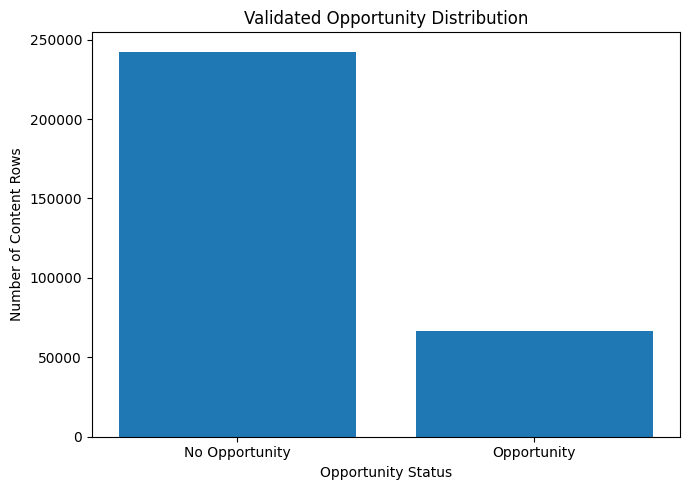

Figure exported to: work/figures/week7_opportunity_distribution.png


In [23]:
# Export figure for the paper

import matplotlib.pyplot as plt

opportunity_counts = model_data["opportunity"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Opportunity", "Opportunity"],
    [
        opportunity_counts.get(0, 0),
        opportunity_counts.get(1, 0)
    ]
)
plt.title("Validated Opportunity Distribution")
plt.xlabel("Opportunity Status")
plt.ylabel("Number of Content Rows")
plt.tight_layout()

figure_path = Path("work/figures/week7_opportunity_distribution.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure exported to:", figure_path)

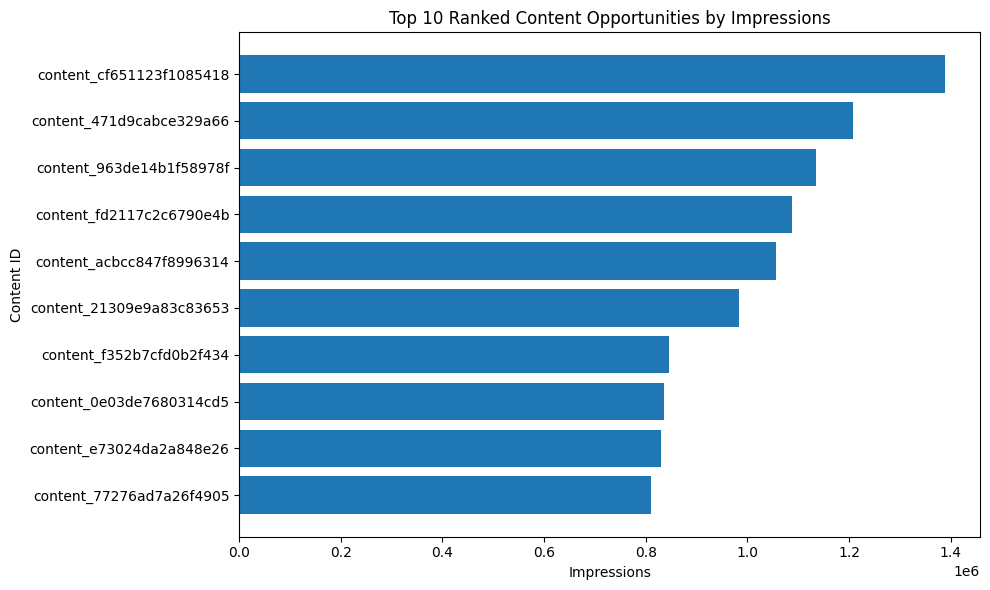

Figure exported to: work/figures/week7_top10_action_queue.png


In [24]:
# Figure 2: Top 10 ranked content opportunities

top10 = action_queue.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top10["content_hash_id"].astype(str),
    top10["impressions"]
)

plt.title("Top 10 Ranked Content Opportunities by Impressions")
plt.xlabel("Impressions")
plt.ylabel("Content ID")
plt.gca().invert_yaxis()
plt.tight_layout()

figure2_path = Path("work/figures/week7_top10_action_queue.png")
plt.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure exported to:", figure2_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.